# Importing Data

Provided are 1610 audio recordings of sustained vowels, either "eeeee" or "oooo".



In [10]:
# check if ../data/ exists, if not: clone git repo and change path repo to that
import os
import csv
import numpy as np

import tensorflow as tf
from tensorflow import keras

keras.utils.set_random_seed(1)

# If using TensorFlow, this will make GPU ops as deterministic as possible,
# but it will affect the overall performance, so be mindful of that.
tf.config.experimental.enable_op_determinism()

import os

os.environ["KERAS_BACKEND"] = "jax"

if not os.path.isdir("../data"):
    print("data directory not found, cloning repository…")
    !rm -rf ./vowel-detection/
    !git clone https://github.com/danielstebbings/vowel-detection
    data_path = "./vowel-detection/data/"
else:
    print("Found data")
    data_path = "../data/"

# Read label csv
with open(data_path+"/train/"+"train_labels.csv", newline='') as csvfile:
    reader = csv.DictReader(csvfile)
    train_labels = []
    for row in reader:
        train_labels.append(int(row['Labels']))

# Import data into keras dataset
train = keras.utils.audio_dataset_from_directory(
    data_path+"train/",
    labels=train_labels,
    label_mode="binary",
    batch_size=None,
    sampling_rate=None,
    output_sequence_length=None,
    ragged=False,
    shuffle=True,
    seed=1, #  Set seed for repeatability.
    validation_split=0.1,
    subset="training",
    follow_links=False,
    verbose=True,
)

val = keras.utils.audio_dataset_from_directory(
    data_path+"train/",
    labels=train_labels,
    label_mode="binary",
    batch_size=None,
    sampling_rate=None,
    output_sequence_length=None,
    ragged=False,
    shuffle=True,
    seed=1, #  Set seed for repeatability.
    validation_split=0.1,
    subset="validation",
    follow_links=False,
    verbose=True,
)

SAMPLE_RATE = 50000
NUM_CLASSES = 2

data directory not found, cloning repository…
Cloning into 'vowel-detection'...
remote: Enumerating objects: 1644, done.
remote: Counting objects: 100% (21/21), done.
remote: Compressing objects: 100% (16/16), done.
remote: Total 1644 (delta 2), reused 20 (delta 2), pack-reused 1623 (from 3)
Receiving objects: 100% (1644/1644), 196.36 MiB | 36.69 MiB/s, done.
Resolving deltas: 100% (2/2), done.
Updating files: 100% (1624/1624), done.
Found 1450 files belonging to 2 classes.
Using 1305 files for training.
Found 1450 files belonging to 2 classes.
Using 145 files for validation.


In [ ]:
# Check out a single sample from the dataset

mostmax, mostmin = 0.0, +np.inf
maxlen,  minlen  = 0,   +np.inf

for sample in train:
    # Sound is a tuple of (data[], label)
    # data[] has a variable size in the 10s of k
    # label is a tensor of 1 value, either 1 or 0.
    #print(sound)
    #print("Data size: "+ str(np.size(sound[0])))
    #print("Label: "+ str(int(sound[1][0])))
    # Find the max max value in dataset
    audio,label = sample

    curmax = np.max(audio)
    curmin = np.min(audio)

    curlen = len(audio)

    if curmax > mostmax:
        mostmax = curmax
    if curmin < mostmin:
        mostmin = curmin

    if curlen > maxlen:
        maxlen = curlen
    elif curlen < minlen:
        minlen = curlen
    
# We're normalised between +-1, so that's nice!
print("most max "+ str(mostmax))
print("most min "+ str(mostmin))

# The length of audio clips varies massively.
print("Longest "+ str(maxlen))
print("Shortest " + str(minlen))


most max 0.98654175
most min -0.9449768
Longest 226236
Shortest 13320


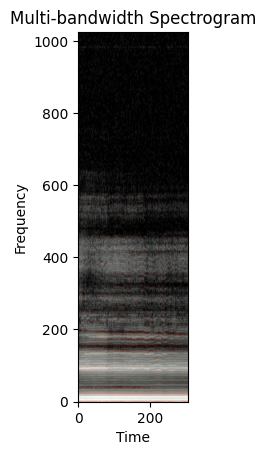

In [ ]:
import matplotlib.pyplot as plt

# Testing out spectrograms.
# So many magic numbers in these Keras examples ...

# From https://keras.io/examples/audio/stft/#define-functions-to-read-and-preprocess-the-wav-files
def plot_multi_bandwidth_spectrogram(sample_wav_data):
    # All spectrograms must use the same `fft_length`, `frame_step`, and
    # `padding="same"` in order to produce spectrograms with identical shapes,
    # hence aligning them together. `expand_dims` ensures that the shapes are
    # compatible with image models.

    spectrograms = np.concatenate(
        [
            keras.layers.STFTSpectrogram(
                mode="log",
                frame_length=SAMPLE_RATE * x // 1000,
                frame_step=SAMPLE_RATE * 4 // 1000,
                fft_length=2048,
                padding="same",
                expand_dims=True,
            )(sample_wav_data[None, ...])[0, ...]
            for x in [8,16,20]
        ],
        axis=-1,
    ).transpose([1, 0, 2])

    # normalize each color channel for better viewing
    mn = spectrograms.min(axis=(0, 1), keepdims=True)
    mx = spectrograms.max(axis=(0, 1), keepdims=True)
    spectrograms = (spectrograms - mn) / (mx - mn)

    plt.imshow(spectrograms, origin="lower")
    plt.title("Multi-bandwidth Spectrogram")
    plt.xlabel("Time")
    plt.ylabel("Frequency")
    plt.show()

for sample in train:
    audio, label = sample
    plot_multi_bandwidth_spectrogram(audio)
    break



## Preprocessing
Let's instead convert the input to a 1D fft and train a dense

In [181]:
BLOCK_LENGTH  = 25000

# Preprocess dataset into blocks
# See: https://stackoverflow.com/questions/47337031/how-to-expand-tf-data-dataset-with-additional-example-transformations-in-tensorf
def to_blocks(audio, label):

    print(f"length: {len(audio)} N blocks: {len(audio)//BLOCK_LENGTH}")
    print("test block it")
    for block_it in range(1, 1+len(audio) // BLOCK_LENGTH):
        print(f"block_it = {block_it}")
        print(f"low={(block_it-1)*BLOCK_LENGTH}")
        print(f"high={(block_it)*BLOCK_LENGTH -1}")

    print(audio)
    print(tf.constant(0,1))
    block = audio[0:BLOCK_LENGTH]
    ds = tf.data.Dataset.from_tensors((block, label))
    print("block_loop")
    for block_it in range(1, 1+len(audio) // BLOCK_LENGTH):
        block = audio[block_it*BLOCK_LENGTH-1:block_it*BLOCK_LENGTH-1 + BLOCK_LENGTH]
        block_ds = tf.data.Dataset.from_tensors((block, label))
        if block_it == 0:
            ds = block_ds
        else:
            ds = ds.concatenate(block_ds)
    return ds

first = True
for sample in train:
    audio, label = sample
    if first:
        train_blocks = to_blocks(audio,sample)
        first = False
    else:
        train_blocks = train_blocks.concatenate(to_blocks(audio,sample))

            

length: 97910 N blocks: 3
test block it
block_it = 1
low=0
high=24999
block_it = 2
low=25000
high=49999
block_it = 3
low=50000
high=74999
tf.Tensor(
[[-0.18807983]
 [-0.19320679]
 [-0.20065308]
 ...
 [-0.24176025]
 [-0.2441101 ]
 [-0.24798584]], shape=(97910, 1), dtype=float32)
tf.Tensor(0.0, shape=(), dtype=float32)
block_loop
length: 67910 N blocks: 2
test block it
block_it = 1
low=0
high=24999
block_it = 2
low=25000
high=49999
tf.Tensor(
[[-0.18988037]
 [-0.19772339]
 [-0.19647217]
 ...
 [ 0.11334229]
 [ 0.11352539]
 [ 0.10800171]], shape=(67910, 1), dtype=float32)
tf.Tensor(0.0, shape=(), dtype=float32)
block_loop
length: 97909 N blocks: 3
test block it
block_it = 1
low=0
high=24999
block_it = 2
low=25000
high=49999
block_it = 3
low=50000
high=74999
tf.Tensor(
[[0.14328003]
 [0.13226318]
 [0.12380981]
 ...
 [0.18234253]
 [0.1882019 ]
 [0.1914978 ]], shape=(97909, 1), dtype=float32)
tf.Tensor(0.0, shape=(), dtype=float32)
block_loop
length: 57682 N blocks: 2
test block it
block_it =

In [182]:
for sample in train_blocks:
    audio, label = sample
    print(len(audio))
    
print(len(train_blocks))

25000
25000
25000
22911
25000
25000
17911
25000
25000
25000
22910
25000
25000
7683
25000
25000
7610
25000
25000
25000
7226
25000
25000
11292
25000
25000
386
25000
25000
25000
17870
25000
25000
12264
25000
25000
4184
25000
25000
4983
25000
25000
19868
25000
25000
17017
25000
25000
25000
22856
25000
25000
1725
25000
25000
1874
25000
25000
2540
25000
25000
25000
7959
25000
10328
25000
25000
25000
20535
25000
11100
25000
25000
13965
25000
25000
25000
6705
25000
25000
14861
25000
25000
17140
25000
10987
25000
25000
25000
11451
25000
25000
25000
22252
25000
25000
25000
557
25000
13847
25000
25000
8188
25000
25000
8595
25000
25000
25000
15782
25000
25000
25000
20534
25000
25000
24989
25000
25000
14641
25000
25000
25000
22198
25000
25000
25000
24812
25000
25000
25000
17752
25000
25000
25000
25000
8946
25000
15877
25000
25000
18121
25000
25000
25000
2
25000
25000
25000
25000
5040
25000
25000
25000
22910
25000
25000
19651
25000
25000
25000
20110
25000
25000
25000
21960
25000
25000
23570
25000
25

# Models


## STFT Based
Working from this example: https://keras.io/examples/audio/stft/

In [93]:
input = keras.layers.Input((None, 1))
spectrograms = [
    keras.layers.STFTSpectrogram(
        mode="log",
        frame_length=SAMPLE_RATE * frame_size // 1000,
        frame_step=SAMPLE_RATE * 15 // 1000,
        fft_length=2048,
        padding="same",
        expand_dims=True,
        # trainable=True,  # trainable by default
    )(input)
    for frame_size in [15, 20, 25]  # frame size in milliseconds
]

multi_spectrograms =  keras.layers.Concatenate(axis=-1)(spectrograms)

img_model = keras.applications.MobileNet(include_top=False, pooling="max")
output = img_model(multi_spectrograms)

output =  keras.layers.Dropout(0.5)(output)
output =  keras.layers.Dense(256, activation="relu")(output)
output =  keras.layers.Dense(256, activation="relu")(output)
output =  keras.layers.Dense(NUM_CLASSES, activation="softmax")(output)
model2d = keras.Model(input, output, name="model_2d_trainble_stft")

model2d.compile(
    optimizer=keras.optimizers.Adam(1e-4),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"],
)
model2d.summary()



/tmp/ipykernel_935/3774027385.py:17: UserWarning: `input_shape` is undefined or non-square, or `rows` is not in [128, 160, 192, 224]. Weights for input shape (224, 224) will be loaded as the default.
  img_model = keras.applications.MobileNet(include_top=False, pooling="max")


Model: "model_2d_trainble_stft"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_23      │ (None, None, 1)   │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stft_spectrogram_95 │ (None, None,      │  1,537,500 │ input_layer_23[0… │
│ (STFTSpectrogram)   │ 1025, 1)          │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stft_spectrogram_96 │ (None, None,      │  2,050,000 │ input_layer_23[0… │
│ (STFTSpectrogram)   │ 1025, 1)          │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stft_spectrogram_97 │ (None, None,      │  2,562,500 │ input_layer_23[0… │
│ (STFTSpectrogram)   │ 1025, 1)          │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_9       │ (None, None,      │          0 │ stft_spectrogram… │
│ (Concatenate)       │ 1025, 3)          │            │ stft_spectrogram… │
│                     │                   │            │ stft_spectrogram… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ mobilenet_1.00_224  │ (None, 1024)      │  3,228,864 │ concatenate_9[0]… │
│ (Functional)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_2 (Dropout) │ (None, 1024)      │          0 │ mobilenet_1.00_2… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_6 (Dense)     │ (None, 256)       │    262,400 │ dropout_2[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_7 (Dense)     │ (None, 256)       │     65,792 │ dense_6[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_8 (Dense)     │ (None, 2)         │        514 │ dense_7[0][0]     │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 9,707,570 (37.03 MB)

 Trainable params: 9,685,682 (36.95 MB)

 Non-trainable params: 21,888 (85.50 KB)

In [94]:
history_model1d = model2d.fit(
    train,
    batch_size=1,
    epochs=10,
    validation_data=val,
)

Epoch 1/10


ResourceExhaustedError: Graph execution error:

Detected at node model_2d_trainble_stft_1/mobilenet_1.00_224_1/conv_dw_1_1/depthwise defined at (most recent call last):
  File "<frozen runpy>", line 198, in _run_module_as_main

  File "<frozen runpy>", line 88, in _run_code

  File "/usr/local/lib/python3.12/dist-packages/colab_kernel_launcher.py", line 37, in <module>

  File "/usr/local/lib/python3.12/dist-packages/traitlets/config/application.py", line 992, in launch_instance

  File "/usr/local/lib/python3.12/dist-packages/ipykernel/kernelapp.py", line 712, in start

  File "/usr/local/lib/python3.12/dist-packages/tornado/platform/asyncio.py", line 211, in start

  File "/usr/lib/python3.12/asyncio/base_events.py", line 645, in run_forever

  File "/usr/lib/python3.12/asyncio/base_events.py", line 1999, in _run_once

  File "/usr/lib/python3.12/asyncio/events.py", line 88, in _run

  File "/usr/local/lib/python3.12/dist-packages/ipykernel/kernelbase.py", line 510, in dispatch_queue